<a href="https://colab.research.google.com/github/anushah-200/factcheckAI/blob/main/notebooks/10_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

sns.set_style("whitegrid")

In [3]:
base_path = "/content/drive/MyDrive/factcheckAI/outputs/"

In [4]:
#features
X_train = pd.read_csv(base_path + "X_train.csv")

X_test = pd.read_csv(base_path + "X_test.csv")


In [6]:
#labels
y_train = pd.read_csv(base_path + "y_train.csv")

y_test = pd.read_csv(base_path + "y_test.csv")

In [7]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [8]:
print("Training Features:", X_train.shape)

print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)

print("Testing Labels:", y_test.shape)

Training Features: (644, 14)
Testing Features: (162, 14)
Training Labels: (644,)
Testing Labels: (162,)


In [9]:
print(y_train.value_counts())

Hallucination
1.0    352
0.0    292
Name: count, dtype: int64


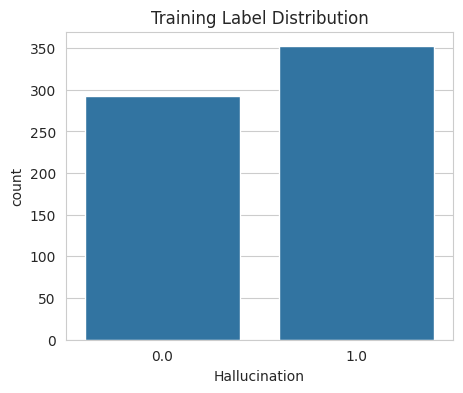

In [10]:
#visualisation
plt.figure(figsize=(5,4))

sns.countplot(
    x=y_train
)

plt.title("Training Label Distribution")

plt.show()

In [11]:
results = []

In [13]:
#training logistic regression
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [14]:
#prediction
y_pred = logistic_model.predict(
    X_test
)

y_prob = logistic_model.predict_proba(
    X_test
)[:,1]

In [15]:
#evaluating logistic regression
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc = roc_auc_score(
    y_test,
    y_prob
)

In [16]:
print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

print("ROC AUC  :", roc)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


In [17]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        74
         1.0       1.00      1.00      1.00        88

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162



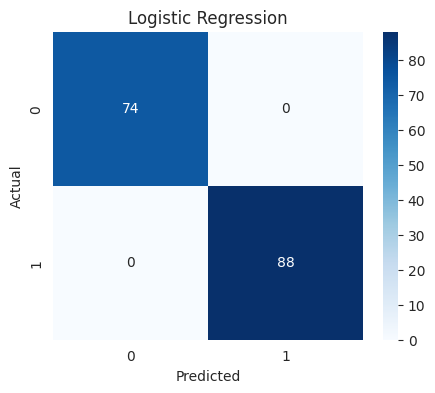

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression")

plt.show()

In [19]:
results.append({

    "Model":"Logistic Regression",

    "Accuracy":accuracy,

    "Precision":precision,

    "Recall":recall,

    "F1":f1,

    "ROC-AUC":roc

})

In [20]:
joblib.dump(

    logistic_model,

    base_path+"logistic_regression.pkl"

)

['/content/drive/MyDrive/factcheckAI/outputs/logistic_regression.pkl']

In [21]:
#decision tree
tree = DecisionTreeClassifier(

    random_state=42

)

tree.fit(

    X_train,

    y_train

)

DecisionTreeClassifier(random_state=42)

In [22]:
tree_pred = tree.predict(
    X_test
)

tree_prob = tree.predict_proba(
    X_test
)[:,1]

In [23]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

tree_precision = precision_score(
    y_test,
    tree_pred
)

tree_recall = recall_score(
    y_test,
    tree_pred
)

tree_f1 = f1_score(
    y_test,
    tree_pred
)

tree_auc = roc_auc_score(
    y_test,
    tree_prob
)

In [24]:
print(classification_report(

    y_test,

    tree_pred

))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        74
         1.0       1.00      1.00      1.00        88

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162



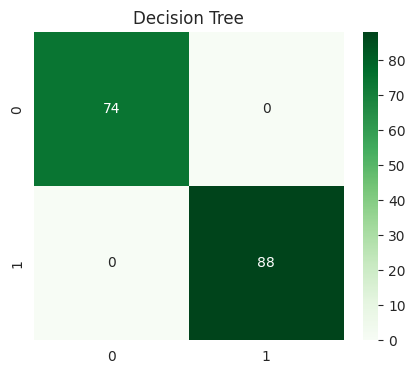

In [25]:
cm = confusion_matrix(
    y_test,
    tree_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    cmap="Greens",

    fmt="d"

)

plt.title("Decision Tree")

plt.show()

In [26]:
results.append({

    "Model":"Decision Tree",

    "Accuracy":tree_accuracy,

    "Precision":tree_precision,

    "Recall":tree_recall,

    "F1":tree_f1,

    "ROC-AUC":tree_auc

})

In [27]:
joblib.dump(

    tree,

    base_path+"decision_tree.pkl"

)

['/content/drive/MyDrive/factcheckAI/outputs/decision_tree.pkl']

In [28]:
#training random forest
forest = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

forest.fit(

    X_train,

    y_train

)

RandomForestClassifier(n_estimators=200, random_state=42)

In [29]:
forest_pred = forest.predict(
    X_test
)

forest_prob = forest.predict_proba(
    X_test
)[:,1]

In [30]:
forest_accuracy = accuracy_score(
    y_test,
    forest_pred
)

forest_precision = precision_score(
    y_test,
    forest_pred
)

forest_recall = recall_score(
    y_test,
    forest_pred
)

forest_f1 = f1_score(
    y_test,
    forest_pred
)

forest_auc = roc_auc_score(
    y_test,
    forest_prob
)

In [31]:
print(classification_report(

    y_test,

    forest_pred

))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        74
         1.0       1.00      1.00      1.00        88

    accuracy                           1.00       162
   macro avg       1.00      1.00      1.00       162
weighted avg       1.00      1.00      1.00       162



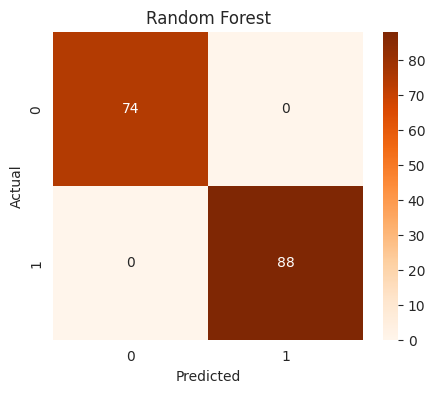

In [32]:
cm = confusion_matrix(
    y_test,
    forest_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Oranges",
    fmt="d"
)

plt.title("Random Forest")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [33]:
results.append({

    "Model":"Random Forest",

    "Accuracy":forest_accuracy,

    "Precision":forest_precision,

    "Recall":forest_recall,

    "F1":forest_f1,

    "ROC-AUC":forest_auc

})

In [34]:
joblib.dump(

    forest,

    base_path+"random_forest.pkl"

)

['/content/drive/MyDrive/factcheckAI/outputs/random_forest.pkl']

In [36]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0


In [37]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0


In [38]:
results_df.to_csv(
    base_path + "model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


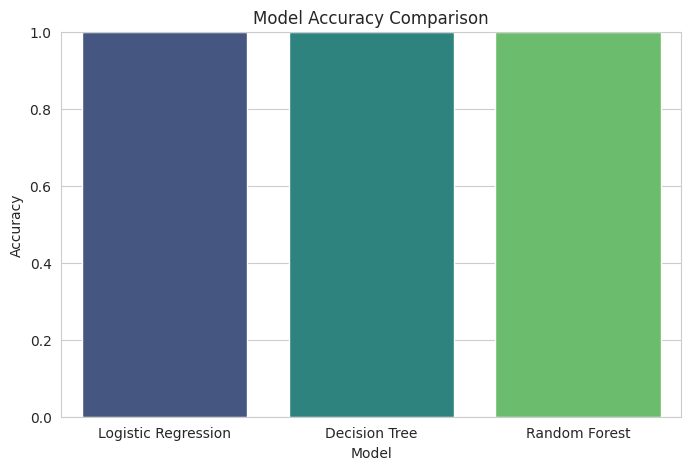

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.show()

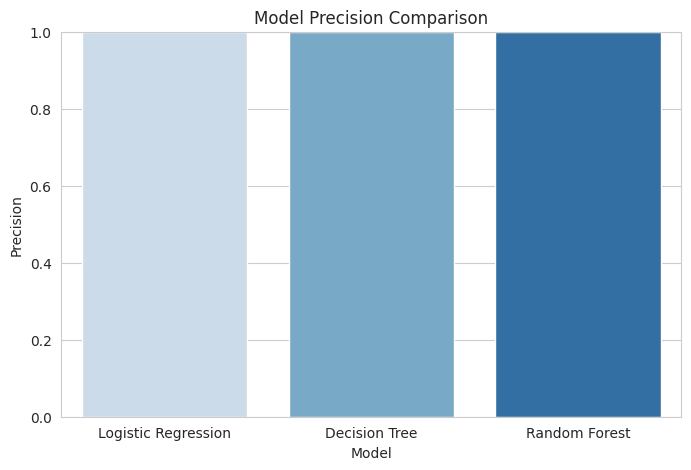

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision",
    hue="Model",
    palette="Blues",
    legend=False
)

plt.title("Model Precision Comparison")

plt.ylim(0,1)

plt.show()

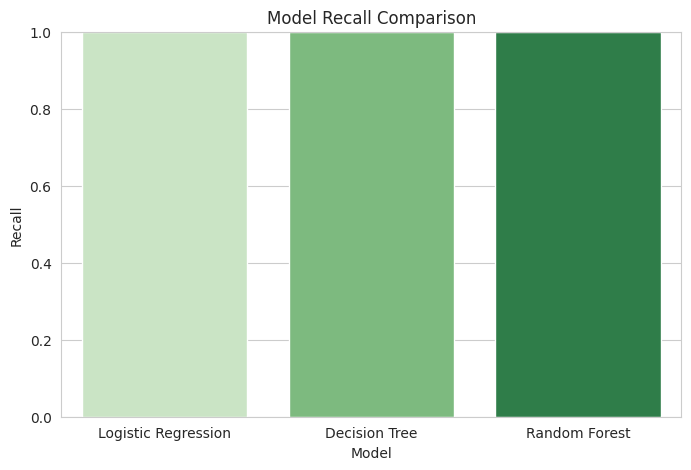

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall",
    hue="Model",
    palette="Greens",
    legend=False
)

plt.title("Model Recall Comparison")

plt.ylim(0,1)

plt.show()

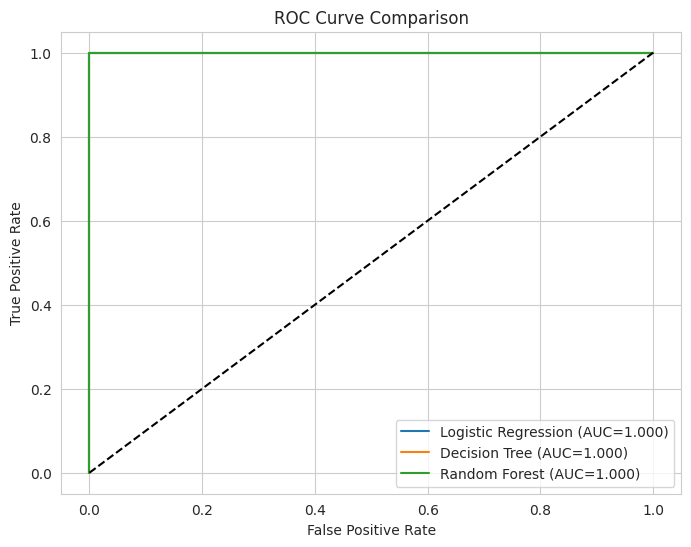

In [42]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC={roc:.3f})"
)

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, tree_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC={tree_auc:.3f})"
)

# Random Forest
fpr, tpr, _ = roc_curve(y_test, forest_prob)

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC={forest_auc:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [43]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": forest.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
7,BERTScore,0.305985
3,SemanticSimilarity,0.214015
5,ROUGE1,0.196610
6,ROUGEL,0.162383
4,BLEU,0.055320
9,GroundTruthLength,0.033904
11,LengthDifference,0.013171
0,Category,0.005602
8,ResponseLength,0.004114
10,QuestionLength,0.004082


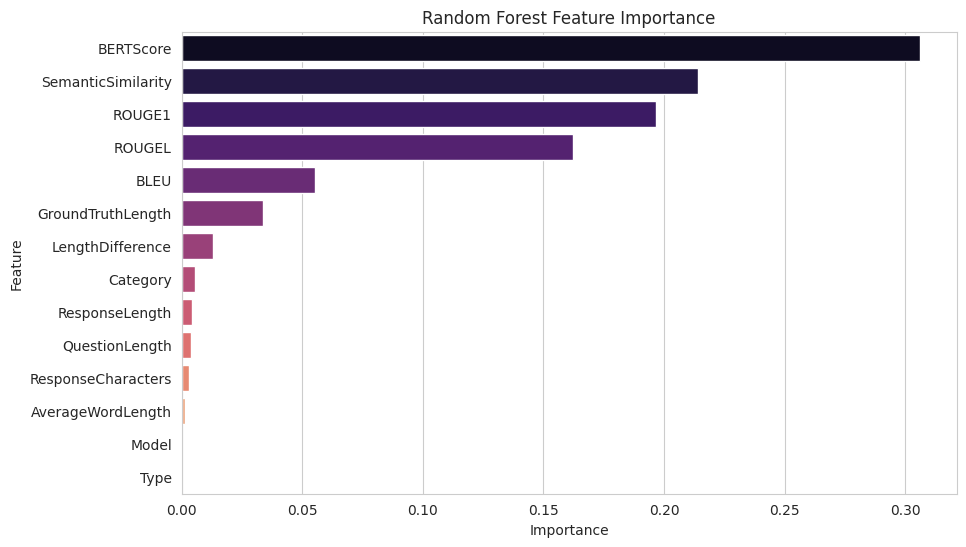

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

In [45]:
importance.to_csv(
    base_path + "feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


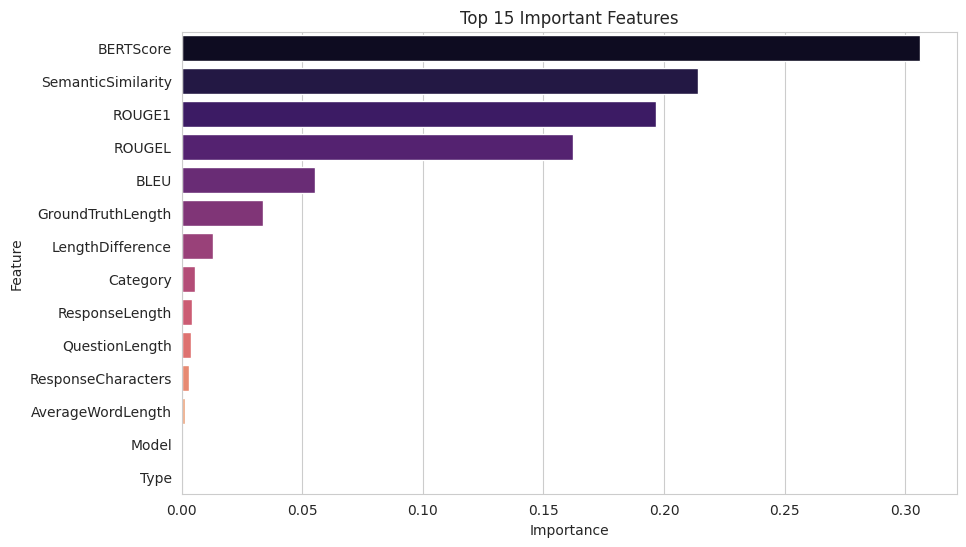

In [50]:
#saving feature importance plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="magma",
    legend=False
)

plt.title("Top 15 Important Features")

plt.savefig(
    base_path + "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

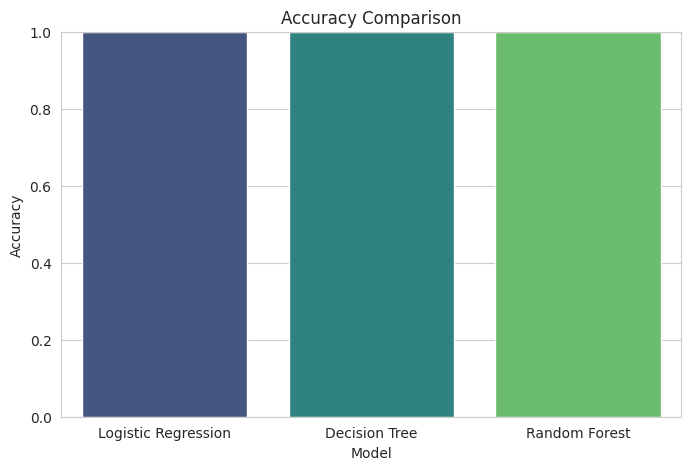

In [51]:
#saving accuracy plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.ylim(0,1)

plt.title("Accuracy Comparison")

plt.savefig(
    base_path + "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
#final results
print("Final Model Performance")

results_df

Final Model Performance


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0


In [53]:
#best model
best_model = results_df.iloc[0]

print("Best Performing Model")

print(best_model)

Best Performing Model
Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1                           1.0
ROC-AUC                      1.0
Name: 0, dtype: object


In [54]:
#verifying output folder
import os

os.listdir(base_path)

['model_metric_summary.csv',
 'potential_hallucinations.csv',
 'category_metric_summary.csv',
 'metric_summary.csv',
 'responses_test.csv',
 'groq_responses.csv',
 'deepseek_responses.csv',
 'openai_responses.csv',
 'evaluation_checkpoint.csv',
 'merged_responses.csv',
 'evaluation_dataset.csv',
 'manual_annotation_sample.csv.gsheet',
 'manual_annotation_sample.csv',
 'manual_review.csv',
 'high_confidence_labels.csv',
 'uncertain_responses.csv',
 'ml_dataset.csv',
 'training_dataset.csv',
 'model_encoder.pkl',
 'category_encoder.pkl',
 'scaler.pkl',
 'X_train.csv',
 'X_test.csv',
 'y_train.csv',
 'y_test.csv',
 'feature_names.pkl',
 'logistic_regression.pkl',
 'decision_tree.pkl',
 'random_forest.pkl',
 'model_comparison.csv',
 'feature_importance.csv',
 'feature_importance.png',
 'accuracy_comparison.png']